In [2]:
# Step 1: check what PyTorch + CUDA version Colab actually has right now
import torch
print("PyTorch:", torch.__version__)        # e.g. 2.6.0+cu130
print("CUDA:   ", torch.version.cuda)       # e.g. 13.0

# Step 2: reinstall torchvision to match, then upgrade everything else
# cu130 = CUDA 13.0  |  change if your output above shows a different version
!pip install -q --upgrade torchvision --extra-index-url https://download.pytorch.org/whl/cu130
!pip install -q --upgrade diffusers transformers accelerate

PyTorch: 2.11.0+cu130
CUDA:    13.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 109.5 MB/s eta 0:00:00


In [1]:
import torch
import time
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from diffusers import AutoPipelineForText2Image

# Check what hardware Colab gave us
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype  = torch.float16 if device == "cuda" else torch.float32
print(f"Device : {device}")
print(f"Dtype  : {dtype}")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
`Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.


Device : cuda
Dtype  : torch.float16


In [2]:
pipe = AutoPipelineForText2Image.from_pretrained(
    "stabilityai/sdxl-turbo",
    torch_dtype=dtype,
    variant="fp16"          # use float16 weights to save VRAM
)
pipe = pipe.to(device)
print("Model loaded successfully.")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Model loaded successfully.


  0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


Generated in 2.37s  |  steps=1


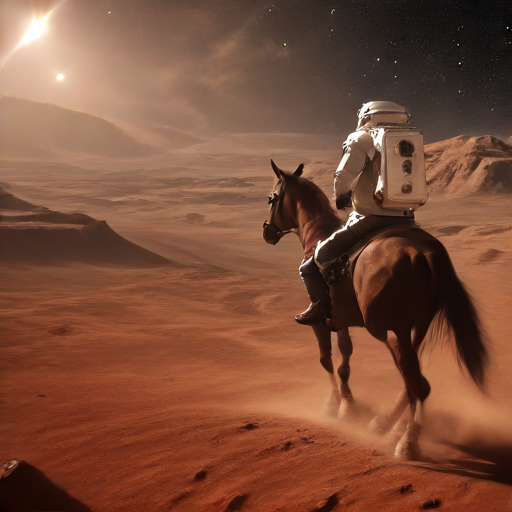

In [3]:
prompt = "a photo of an astronaut riding a horse on mars, photorealistic, 4k"

t_start = time.time()
result  = pipe(
    prompt=prompt,
    num_inference_steps=1,   # ← the entire point of this paper
    guidance_scale=0.0,      # ← required for SDXL-Turbo
)
t_end = time.time()

image_1step = result.images[0]
print(f"Generated in {t_end - t_start:.2f}s  |  steps=1")
image_1step.save("sdxl_turbo_1step.png")
image_1step

In [4]:
prompts = [
    "a photorealistic mountain landscape at golden hour, cinematic, 8k",
    "a futuristic city skyline at night with neon lights, detailed",
    "a watercolor painting of a fox in a forest, soft lighting",
]

step_counts = [1, 2, 4]
results = {}   # {steps: [img, img, img]}

for n in step_counts:
    imgs = []
    t0 = time.time()
    for p in prompts:
        img = pipe(
            prompt=p,
            num_inference_steps=n,
            guidance_scale=0.0,
        ).images[0]
        imgs.append(img)
    elapsed = time.time() - t0
    results[n] = (imgs, elapsed)
    print(f"steps={n}  |  3 images in {elapsed:.2f}s  ({elapsed/3:.2f}s each)")

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

steps=1  |  3 images in 2.11s  (0.70s each)


  0%|          | 0/2 [00:00<?, ?it/s]

...

steps=2  |  3 images in 2.37s  (0.79s each)


  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

steps=4  |  3 images in 3.10s  (1.03s each)


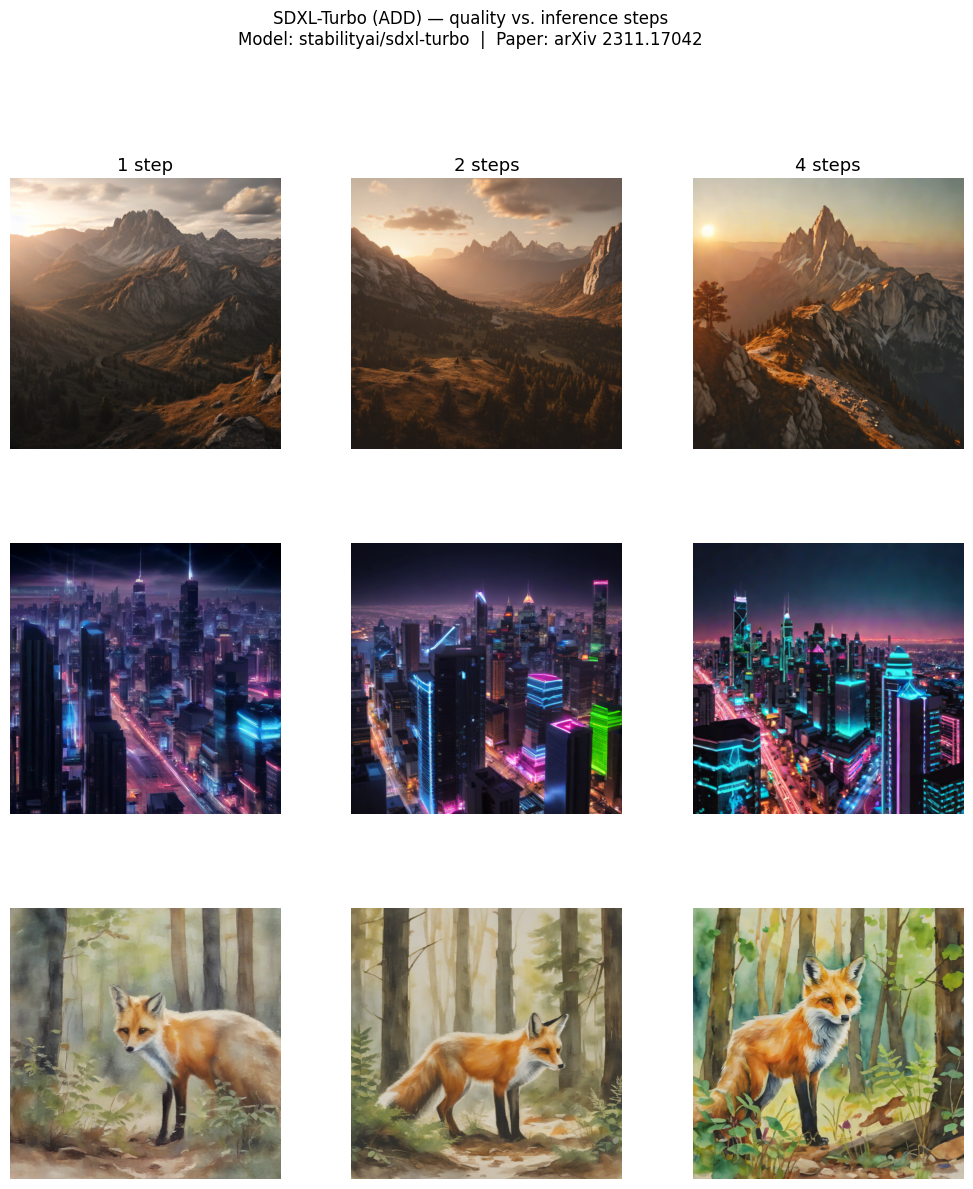

Saved: sdxl_turbo_grid.png  ← screenshot this for your slides


In [5]:
fig = plt.figure(figsize=(13, 13))
gs  = gridspec.GridSpec(3, 3, hspace=0.35, wspace=0.05)

col_labels = ["1 step", "2 steps", "4 steps"]
row_labels  = ["Prompt 1\n(landscape)", "Prompt 2\n(city)", "Prompt 3\n(painting)"]

for row_i, prompt_label in enumerate(row_labels):
    for col_i, n in enumerate(step_counts):
        ax = fig.add_subplot(gs[row_i, col_i])
        ax.imshow(results[n][0][row_i])
        ax.axis("off")
        if row_i == 0:
            ax.set_title(col_labels[col_i], fontsize=13, pad=6)
        if col_i == 0:
            ax.set_ylabel(prompt_label, fontsize=10, labelpad=8)

fig.suptitle(
    "SDXL-Turbo (ADD) — quality vs. inference steps\n"
    "Model: stabilityai/sdxl-turbo  |  Paper: arXiv 2311.17042",
    fontsize=12, y=1.01
)
plt.savefig("sdxl_turbo_grid.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sdxl_turbo_grid.png  ← screenshot this for your slides")

In [6]:
from diffusers import DiffusionPipeline

pipe_lcm = DiffusionPipeline.from_pretrained(
    "SimianLuo/LCM_Dreamshaper_v7",   # LCM distilled from SD 1.5
    torch_dtype=dtype,
)
pipe_lcm = pipe_lcm.to(device)

compare_prompt = "a photorealistic mountain landscape at golden hour, cinematic, 8k"

# SDXL-Turbo: 1 step
t0 = time.time()
img_turbo = pipe(compare_prompt, num_inference_steps=1, guidance_scale=0.0).images[0]
t_turbo   = time.time() - t0

# LCM: 1 step
t0 = time.time()
img_lcm = pipe_lcm(
    compare_prompt,
    num_inference_steps=1,
    guidance_scale=8.0,
    lcm_origin_steps=50,
).images[0]
t_lcm = time.time() - t0

# LCM: 4 steps (its recommended sweet spot)
t0 = time.time()
img_lcm4 = pipe_lcm(
    compare_prompt,
    num_inference_steps=4,
    guidance_scale=8.0,
    lcm_origin_steps=50,
).images[0]
t_lcm4 = time.time() - t0

print(f"SDXL-Turbo 1-step : {t_turbo:.2f}s")
print(f"LCM        1-step : {t_lcm:.2f}s")
print(f"LCM        4-step : {t_lcm4:.2f}s")


model_index.json:   0%|          | 0.00/588 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

SDXL-Turbo 1-step : 0.79s
LCM        1-step : 1.03s
LCM        4-step : 1.43s


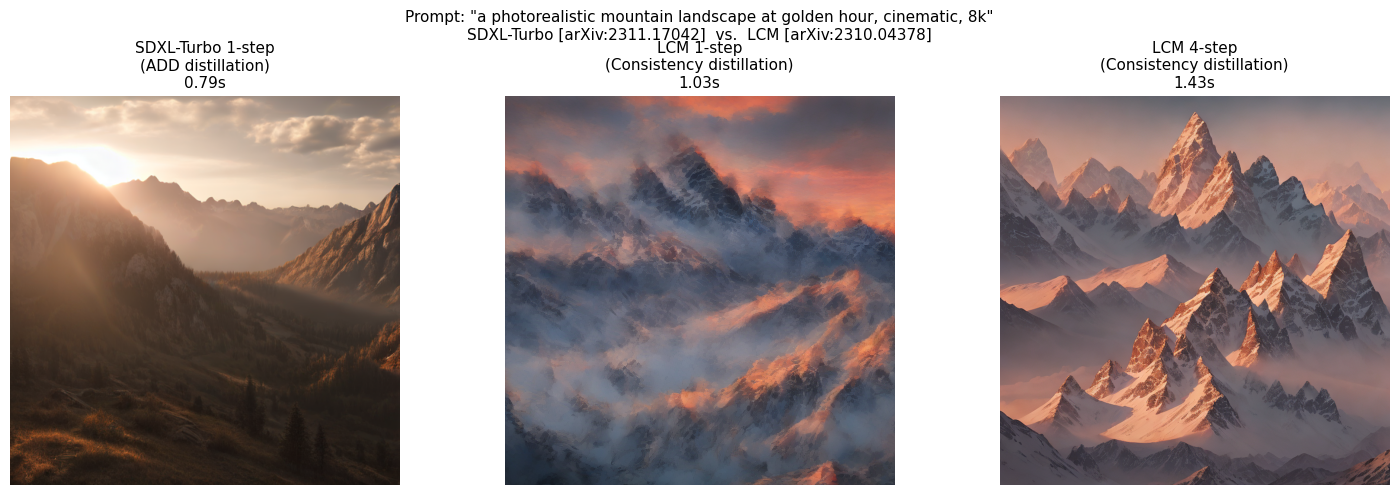

Saved: method_comparison.png  ← use this in the comparison slide

RESULTS SUMMARY
SDXL-Turbo  1 step  → 0.79s  (ADD, arXiv:2311.17042)
LCM         1 step  → 1.03s  (CD,  arXiv:2310.04378)
LCM         4 steps → 1.43s  (CD,  arXiv:2310.04378)
-------------------------------------------------------
Standard SDXL (25 steps) baseline: ~8-12s on T4
Speedup demonstrated: ~10-20x

Files saved:
  sdxl_turbo_1step.png   — single image output
  sdxl_turbo_grid.png    — 3×3 quality sweep grid
  method_comparison.png  — side-by-side SDXL-Turbo vs LCM

Use these screenshots directly in your slides.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

data = [
    (img_turbo, f"SDXL-Turbo 1-step\n(ADD distillation)\n{t_turbo:.2f}s"),
    (img_lcm,   f"LCM 1-step\n(Consistency distillation)\n{t_lcm:.2f}s"),
    (img_lcm4,  f"LCM 4-step\n(Consistency distillation)\n{t_lcm4:.2f}s"),
]

for ax, (img, label) in zip(axes, data):
    ax.imshow(img)
    ax.set_title(label, fontsize=11)
    ax.axis("off")

fig.suptitle(
    f'Prompt: "{compare_prompt}"\n'
    "SDXL-Turbo [arXiv:2311.17042]  vs.  LCM [arXiv:2310.04378]",
    fontsize=11
)
plt.tight_layout()
plt.savefig("method_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: method_comparison.png  ← use this in the comparison slide")


# ── CELL 9: Print timing summary ────────────────────────────
print("\n" + "="*55)
print("RESULTS SUMMARY")
print("="*55)
print(f"SDXL-Turbo  1 step  → {t_turbo:.2f}s  (ADD, arXiv:2311.17042)")
print(f"LCM         1 step  → {t_lcm:.2f}s  (CD,  arXiv:2310.04378)")
print(f"LCM         4 steps → {t_lcm4:.2f}s  (CD,  arXiv:2310.04378)")
print("-"*55)
print("Standard SDXL (25 steps) baseline: ~8-12s on T4")
print("Speedup demonstrated: ~10-20x")
print("="*55)
print("\nFiles saved:")
print("  sdxl_turbo_1step.png   — single image output")
print("  sdxl_turbo_grid.png    — 3×3 quality sweep grid")
print("  method_comparison.png  — side-by-side SDXL-Turbo vs LCM")
print("\nUse these screenshots directly in your slides.")